# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import plot_temperature_triptych

In [2]:
steps = {
    0:  100,
    1:   99,
    2:   98,
    3:   96,
    4:   95,
    5:   94,
    6:   92,
    7:   90,
    8:   89,
    9:   87,
    10:  85,
    11:  83,
    12:  81,
    13:  79,
    14:  76,
    15:  74,
    16:  71,
    17:  68,
    18:  65,
    19:  61,
    20:  58,
    21:  54,
    22:  49,
    23:  44,
    24:  39,
    25:  33,
    26:  26,
    27:  19,
    28:  10,
    29:   1,
}

In [3]:
lam = 1.5
n_replicas = 2
n_samples = 1

swap_algorithm = {
	"p_ratio" : "p",
	"even": [ steps[14], steps[18], steps[22]],
	"odd":  [ steps[15], steps[19], steps[23]],
	"debug" : True
}

# Composed Dataset

Running best-of-4...
 diff -0.27906596660614014
p ratio.         1.0949811935424805 std 0.4966832399368286
Time 76 swap btwn source 1.00 and target 1.50 accept 0.94 
 diff -0.5022986531257629
p ratio.         1.0955229997634888 std 0.6447114944458008
Time 74 swap btwn source 0.67 and target 1.50 accept 0.92 
 diff -0.3776892423629761
p ratio.         0.9837693572044373 std 0.3509520888328552
Time 65 swap btwn source 1.00 and target 1.50 accept 0.91 
 diff -0.6690842509269714
p ratio.         1.2063173055648804 std 1.7789278030395508
Time 61 swap btwn source 0.67 and target 1.50 accept 0.93 
 diff -0.4488809108734131
p ratio.         1.0198296308517456 std 0.4938543736934662
Time 49 swap btwn source 1.00 and target 1.50 accept 0.93 
 diff -0.7692545056343079
p ratio.         1.180890440940857 std 3.13277268409729
Time 44 swap btwn source 0.67 and target 1.50 accept 0.92 
  Run 1/4  mean_ll=-4.2457  best_so_far=-4.2457
 diff -0.27906596660614014
p ratio.         1.0953201055526733 std 0.

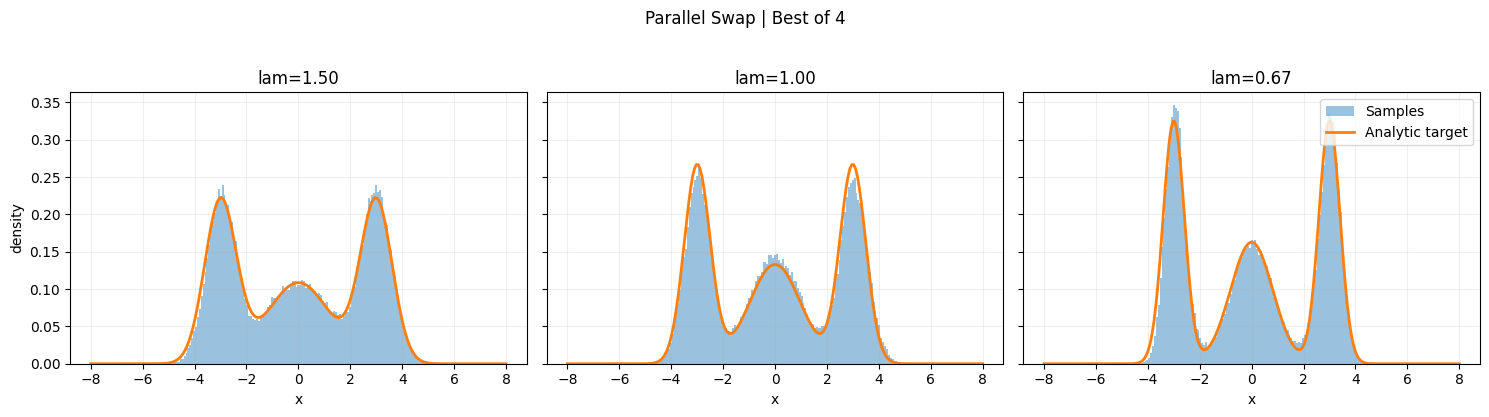

In [4]:
_ = plot_temperature_triptych(
	dataset_name="composed",
	lam=lam,
	n_samples=n_samples,
	n_replicas=n_replicas,
	replica_swaps=True,
	swap_algorithm=swap_algorithm,
 	best_of_n_runs=4
)

Running best-of-4...
  Run 1/4  mean_ll=-4.6675  best_so_far=-4.6675
  Run 2/4  mean_ll=-4.6582  best_so_far=-4.6582
  Run 3/4  mean_ll=-4.6691  best_so_far=-4.6582
  Run 4/4  mean_ll=-4.6630  best_so_far=-4.6582

Best run score: -4.6582  (across 4 runs)
Best score: -4.6582 | All scores: ['-4.6675', '-4.6582', '-4.6691', '-4.6630']


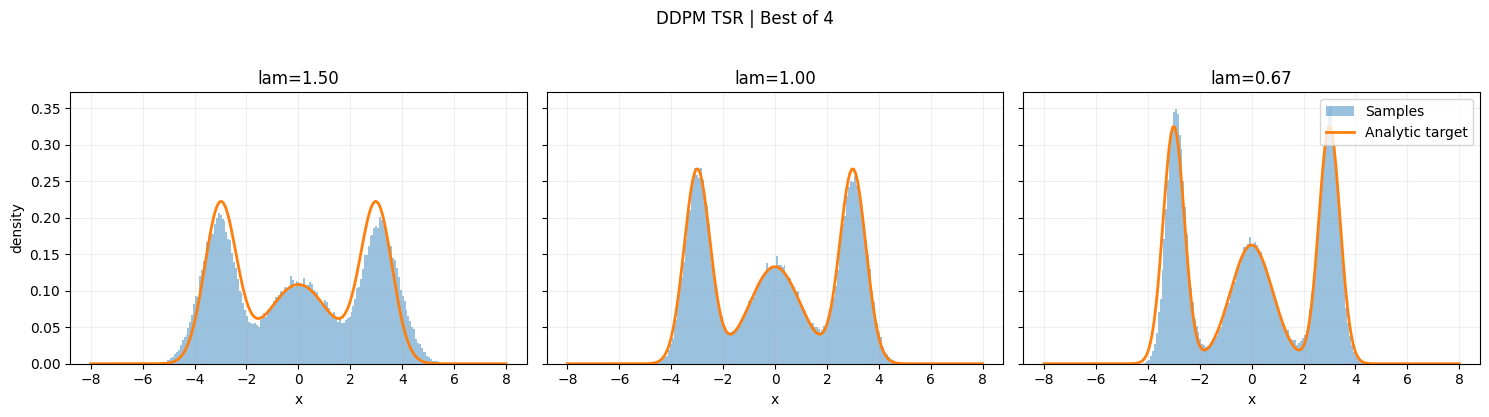

In [5]:
_ = plot_temperature_triptych(
	dataset_name="composed",
	lam=lam,
	n_samples=n_samples,
	n_replicas=n_replicas,
	replica_swaps=False,
	swap_algorithm=swap_algorithm,
  	best_of_n_runs=4
)

# MNIST Dataset

In [6]:
# _ = plot_temperature_triptych(
# 	dataset_name="mnist",
# 	k=0.5,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=False,
# 	swap_algorithm=swap_algorithm
# )

In [7]:
# _ = plot_temperature_triptych(
# 	dataset_name="mnist",
# 	k=2.0,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=False,
# 	swap_algorithm=swap_algorithm
# )

# Best of N

In [8]:
# _ = plot_temperature_triptych(
# 	dataset_name="composed",
# 	k=k,
# 	n_samples=n_samples,
# 	n_replicas=n_replicas,
# 	replica_swaps=True,
# 	swap_algorithm=swap_algorithm,
# 	best_of_n_runs=4
# )